In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.optimize import curve_fit as cf
from scipy.stats import kstest
from scipy.special import gamma
from scipy.signal import lombscargle
from scipy.signal import find_peaks as fp
from scipy.stats import norm,beta

In [3]:
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6
mpl.rcParams['figure.autolayout'] = True
mpl.rcParams['font.size'] = 15
mpl.rcParams['errorbar.capsize'] = 3
mpl.rcParams['lines.markeredgewidth'] = 1
mpl.rcParams['axes.axisbelow'] = True

In [4]:
cent_dict = {25 : 1, 26 : 2, 27 : 3, 28 : 4, 29 : 5, 30 : 6, 31 : 7, 32 : 8,
    57 : 16, 58 : 15, 59 : 14, 60 : 13, 61 : 12, 62 : 11, 63 : 10, 64 : 9}

valid_pairs = [[1,9], [2,10], [3,11], [4,12], [5,13], [6,14], [7,15], [8,16]]

def read_df(path):
    df = pd.read_csv(path,delimiter=',',dtype=str,header=None,
                     names=['clock_RB','hex','clock_FPGA','ang','count'])
    df['bin'] = df['hex'].apply(lambda x: bin(int(x, 16))[2:].zfill(len(x)*4))
    df['dets'] = df.bin.apply(lambda b: [i+1 for i, bit in enumerate(b) if bit == '1'])
    for i in range(len(df.dets)):
        for j in range(len(df.dets[i])):
            df.dets[i][j] = cent_dict[df.dets[i][j]]
    df_new = pd.DataFrame({'t':df['clock_FPGA'].astype(int),'ang':df['ang'].astype(int),
                           'counts':df['count'].astype(int),'dets':df['dets']})
    return df_new

def correct_clock(df):
    drops = []
    check = True
    while check:
        for i in range(1,len(df)):
            if df.t.iloc[i] <= df.t[i-1]:
                drops.append(i)
        print(len(drops)/len(df))
        df = df.copy().drop(drops).reset_index(drop=True)
        drops = []
        for i in range(1,len(df)):
            if df.t.iloc[i] <= df.t[i-1]:
                drops.append(i)
        if len(drops) == 0:
            check = False
    return df

lower_ang = 161.5
upper_ang = 5335
def filtrar_ang(df,lower_ang,upper_ang):
    drops = []
    delta = upper_ang-lower_ang
    for i in range(len(df)):
        if df.ang.iloc[i] < lower_ang or df.ang.iloc[i] > upper_ang:
            drops.append(i)
    print(len(drops)/len(df))
    df = df.copy().drop(drops).reset_index(drop=True)
    df['ang'] = (df.ang-lower_ang)*360/delta
    
    return df

def filtrar_coincidencias(df,valid_pairs):
    df = df[df.dets.isin(valid_pairs)]
    df = df.reset_index(drop=True)
    return df

In [5]:
df1 = read_df('MEDICIONES/umbral up/11/2025_11_04_06h00_muontumbler-m101.txt')
for day in ['05','06','07','08','09']:
    df_new = read_df(f'MEDICIONES/umbral up/11/2025_11_{day}_06h00_muontumbler-m101.txt')
    df1 = pd.concat([df1,df_new]).reset_index(drop=True)
df1 = correct_clock(df1)
df1 = filtrar_ang(df1,lower_ang,upper_ang)

df2 = read_df('MEDICIONES/umbral up pt2/11/2025_11_09_06h00_muontumbler-m101.txt')
for day in [10,11,12,13,14,15,16]:
    df_new = read_df(f'MEDICIONES/umbral up pt2/11/2025_11_{day}_06h00_muontumbler-m101.txt')
    df2 = pd.concat([df2,df_new]).reset_index(drop=True)

df2 = correct_clock(df2)
df2 = filtrar_ang(df2,lower_ang,upper_ang)
df = pd.concat([df1,df2])
filtered_df = filtrar_coincidencias(df,valid_pairs)
filtered_df

0.00022890104607778058
0.0005952789797834101
0.00026188722481381457
0.0006221450907840665


,t,ang,counts,dets
0,8468074984,75.882865,697,"[1, 9]"
1,10834547147,292.223833,731,"[2, 10]"
2,10970454362,84.093940,734,"[8, 16]"
3,11462319595,192.925486,743,"[2, 10]"
4,11630049749,214.079443,744,"[2, 10]"
...,...,...,...,...
8154,5992401964304,261.327921,1656,"[2, 10]"
8155,5993740033187,81.171354,1660,"[1, 9]"
8156,5993753892306,24.389678,1661,"[1, 9]"
8157,5997440378270,133.221224,1688,"[2, 10]"


In [6]:
print(f'Primera medición: {np.round((df1.t.iloc[-1]-df1.t.iloc[0])*1e-7/60/60/24,1)} días')
print(f'Segunda medición: {np.round((df2.t.iloc[-1]-df2.t.iloc[0])*1e-7/60/60/24,1)} días')

Primera medición: 5.0 días
Segunda medición: 6.9 días


[list([1, 9]) list([2, 10]) list([3, 11]) list([4, 12]) list([5, 13])
 list([6, 14]) list([7, 15]) list([8, 16])] [2737 2524   10    6   13    4   11 2854]


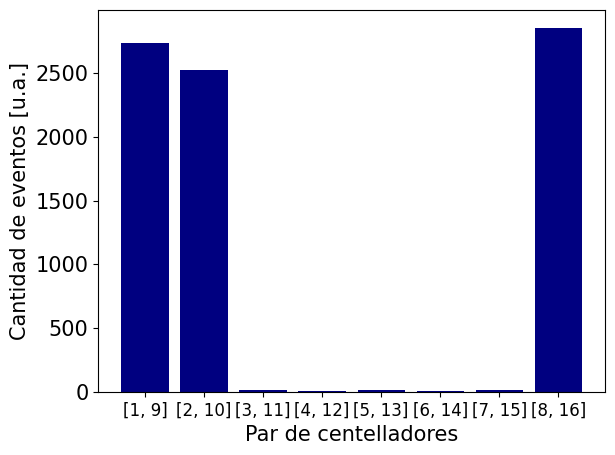

In [34]:
x,y = np.unique(filtered_df.dets,return_counts=True)
plt.bar(np.arange(len(y)),y,color='navy')
locs,labels = plt.xticks()
plt.xticks(ticks=np.arange(len(y)),labels=x,fontsize=12)
plt.xlabel('Par de centelladores')
plt.ylabel('Cantidad de eventos [u.a.]',fontsize=15)
plt.tight_layout()
plt.savefig('plots informe/cantidad por par.png')
print(x,y)

[0.11582418] [8.63377609]


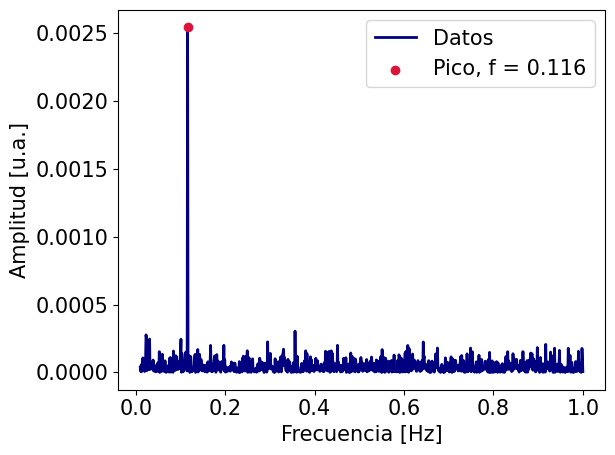

[0.11582418 0.76461538 0.89417582] [8.63377609 1.30784708 1.11834829]


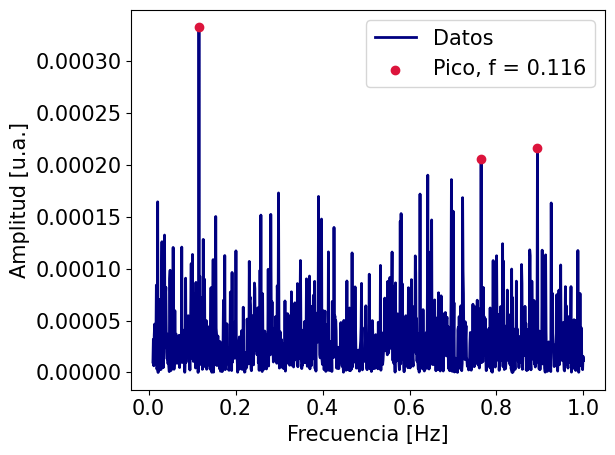

In [17]:
freqs = np.linspace(0.01,1,1002)*1e-7
t = df1.t
ang = df1.ang
powers = lombscargle(t,ang-np.mean(ang),freqs*2*np.pi,normalize=True)
pk_idxs,_ = fp(powers,height=0.001)
plt.plot(freqs*1e7,powers,color='navy',label='Datos',zorder=1)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [u.a.]')
f_pks = freqs[pk_idxs]*1e7
T_pks = 1/f_pks
print(f_pks,T_pks)
plt.scatter(freqs[pk_idxs]*1e7,powers[pk_idxs],color='crimson',label=f'Pico, f = {np.round(f_pks[0],3)}',zorder=2)
plt.legend()
plt.tight_layout()
plt.show()
t = df2.t
ang = df2.ang
powers = lombscargle(t,ang-np.mean(ang),freqs*2*np.pi,normalize=True)
pk_idxs,_ = fp(powers,height=0.0002)
plt.plot(freqs*1e7,powers,color='navy',label='Datos',zorder=1)
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [u.a.]')
f_pks = freqs[pk_idxs]*1e7
T_pks = 1/f_pks
print(f_pks,T_pks)
plt.scatter(freqs[pk_idxs]*1e7,powers[pk_idxs],color='crimson',label=f'Pico, f = {np.round(f_pks[0],3)}',zorder=2)
plt.legend()
plt.tight_layout()

p-valor de Kolmogorov: 0.7593773613228763


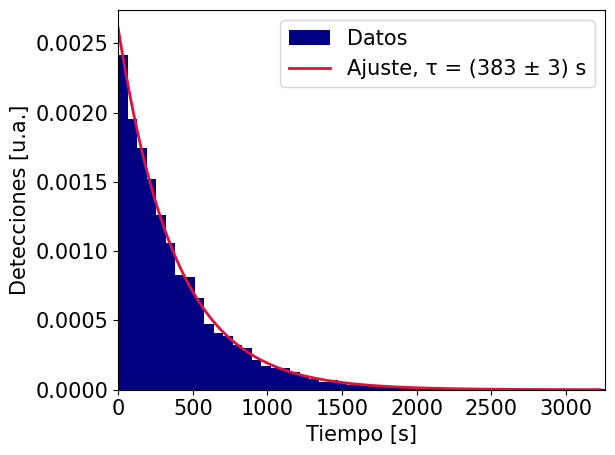

In [35]:
my_pairs = [[1,9],[2,10],[8,16]]
exp_d = lambda x,t : 1/t*np.exp(-x/t)

t_diffs = []
for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    t_diffs.extend(np.diff(df_pair.t*1e-7))
t_diffs = np.array(t_diffs)
t_diffs = t_diffs[t_diffs>=0]
n,bins,_ = plt.hist(t_diffs,bins=51,density=True,color='navy',label='Datos')
x_hist = bins[:-1] + np.diff(bins)/2
y_hist = n
pars,cov = cf(exp_d,x_hist,y_hist,p0=[400])
tau = pars[0]
err_tau = cov[0,0]
x_adj = np.linspace(0,np.max(x_hist),1000)
y_adj = exp_d(x_adj,*pars)
plt.plot(x_adj,y_adj,color='crimson',label=f'Ajuste, \u03C4 = ({pars[0]:.0f} \u00b1 {np.sqrt(cov[0,0]):.0f}) s')
plt.xlim(0,bins[-1])
plt.legend()
plt.xlabel('Tiempo [s]')
plt.ylabel('Detecciones [u.a.]')
plt.tight_layout()

exp_cdf = lambda x : 1 - np.exp(-x/tau)
print(f'p-valor de Kolmogorov: {kstest(t_diffs,exp_cdf).pvalue}')
plt.savefig('plots informe/exponenciales.png')

In [10]:
130-180

-50

In [14]:
print(np.degrees(np.array(fases_posta)-fases_posta[0]))
print((np.array([1,2,0])-1)*18.7)

[  0.          19.60579849 -27.95374104]
[  0.   18.7 -18.7]


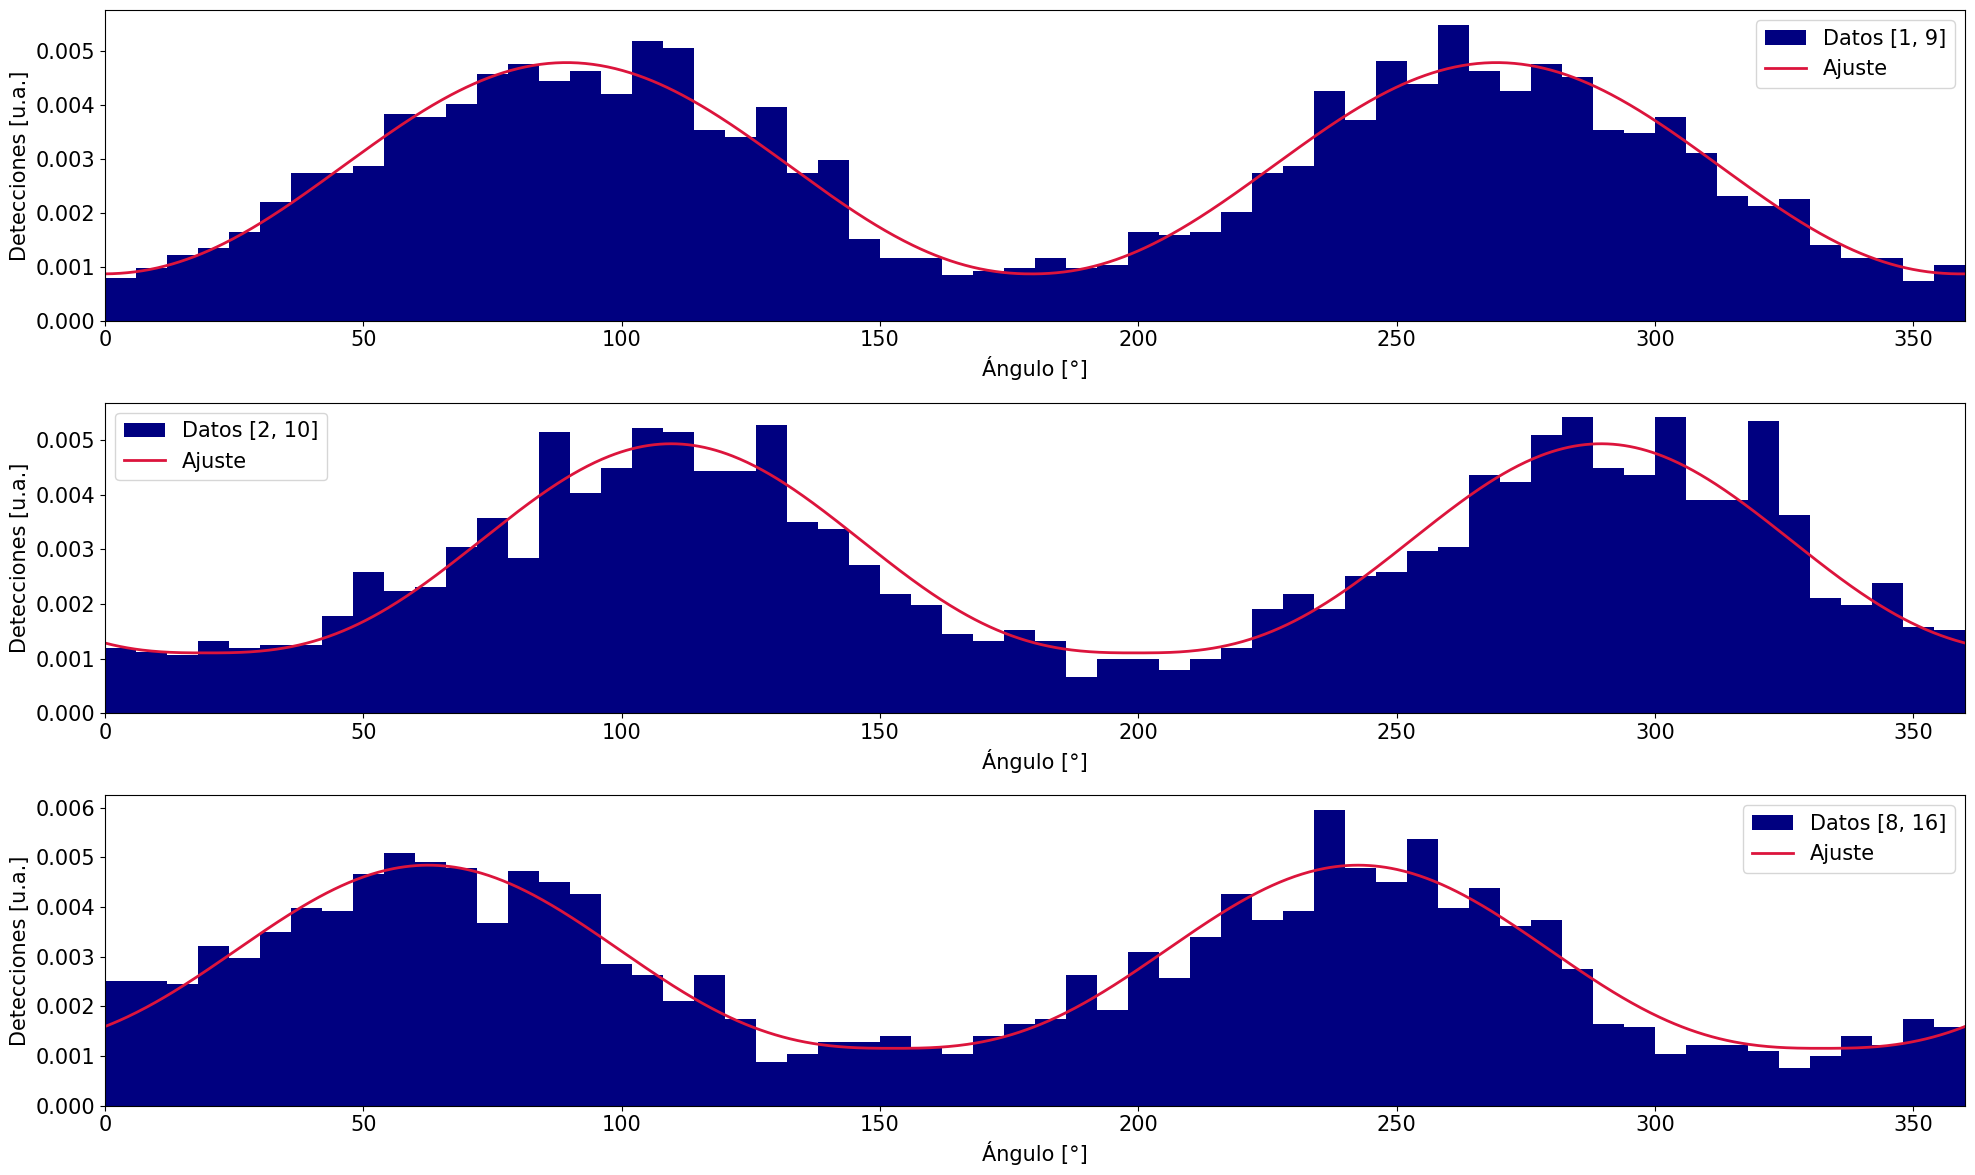

In [53]:
my_pairs = [[1,9],[2,10],[8,16]]
func = lambda x,A,n,phi,C : A*np.abs(np.cos(np.radians(x+phi)))**n + C
bin_width = 9.619727799698852*2
bin_number = 61

fig,axs = plt.subplots(3,1,figsize=(20,12),layout='tight')
axs = axs.flatten()
fases = []

for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    
    n,bins,_ = axs[i].hist(df_pair.ang,bins=np.linspace(0,360,bin_number),density=True,color='navy',label=f'Datos {pair}')
    x = bins[:-1] + np.diff(bins)/2
    y = n
    pars,cov = cf(func,x,y,p0=[np.max(n),2,90,np.min(n)])
    n_m = pars[1]
    err_n_m = np.sqrt(cov[1,1])
    phi = pars[2]
    fases.append(phi)
    err_phi = np.sqrt(cov[2,2])
    C = pars[3]
    A = pars[0]
    x_adj = np.linspace(0,360,1000)
    y_adj = func(x_adj,*pars)
    axs[i].plot(x_adj,y_adj,color='crimson',label=f'Ajuste')
    axs[i].set_xlim(0,360)#bins[-1])
    axs[i].legend()
    axs[i].set_xlabel('Ángulo [°]')
    axs[i].set_ylabel('Detecciones [u.a.]')
plt.savefig('plots informe/ajuste por pares original.png')

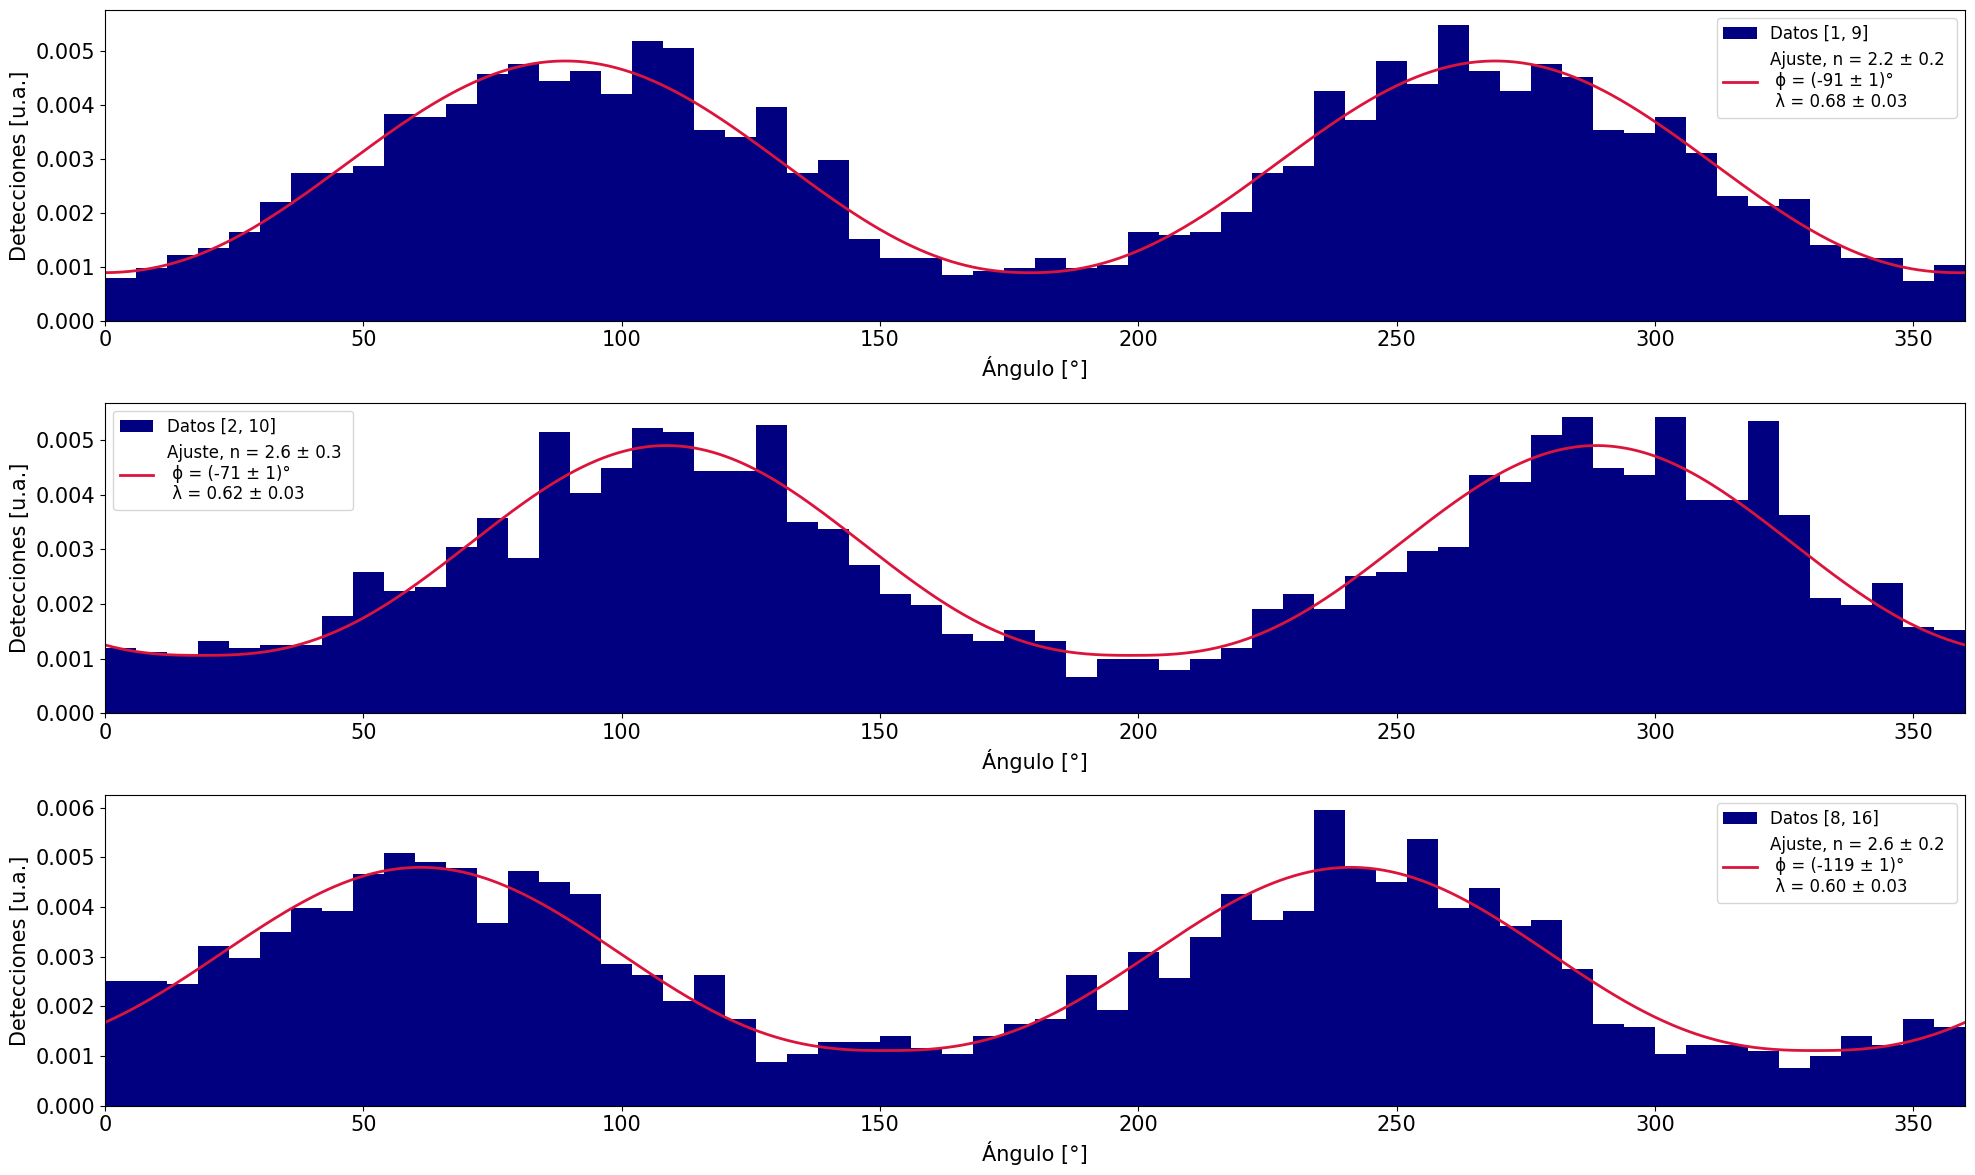

In [7]:
my_pairs = [[1,9],[2,10],[8,16]]
conversion_factor = np.pi/180
bin_width = 9.619727799698852*2
bin_number = 61

fig,axs = plt.subplots(3,1,figsize=(20,12),layout='tight')
axs = axs.flatten()

fases_posta = []

for i in range(len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    results = pd.read_csv(f'bayesian/ajuste {pair}.csv',header=None,names=['n','phi','lambda'])
    n_samples = np.array(results.n)
    phi_samples = np.array(results.phi)
    lambda_samples = np.array(results['lambda'])
    n_m = np.mean(n_samples)
    err_n = np.std(n_samples)
    phi_m = np.mean(phi_samples)
    err_phi = np.std(phi_samples)
    lambda_m = np.mean(lambda_samples)
    err_lambda = np.std(lambda_samples)
    fases_posta.append(phi_m)

    x_adj = np.linspace(0,360,1000)
    Z_val = 2*np.sqrt(np.pi)*gamma((n_m+1)/2)/gamma(n_m/2+1)
    y_muon = (np.abs(np.cos(np.radians(x_adj)-phi_m))**n_m)/Z_val*conversion_factor
    y_ruido = np.full_like(x_adj,1/(2*np.pi))*conversion_factor
    y_adj = (lambda_m*y_muon)+((1-lambda_m)*y_ruido)
    
    axs[i].hist(df_pair.ang,bins=np.linspace(0,360,bin_number),density=True,color='navy',label=f'Datos {pair}')
    axs[i].plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {n_m:.1f} \u00b1 {err_n:.1f} \n \u03d5 = ({np.degrees(phi_m):.0f} \u00b1 {np.degrees(err_phi):.0f})° \n \u03bb = {lambda_m:.2f} \u00b1 {err_lambda:.2f}')
    axs[i].set_xlim(0,360)
    axs[i].legend(fontsize=12)
    axs[i].set_xlabel('Ángulo [°]')
    axs[i].set_ylabel('Detecciones [u.a.]')
plt.savefig('plots informe/ajustes pares.png')

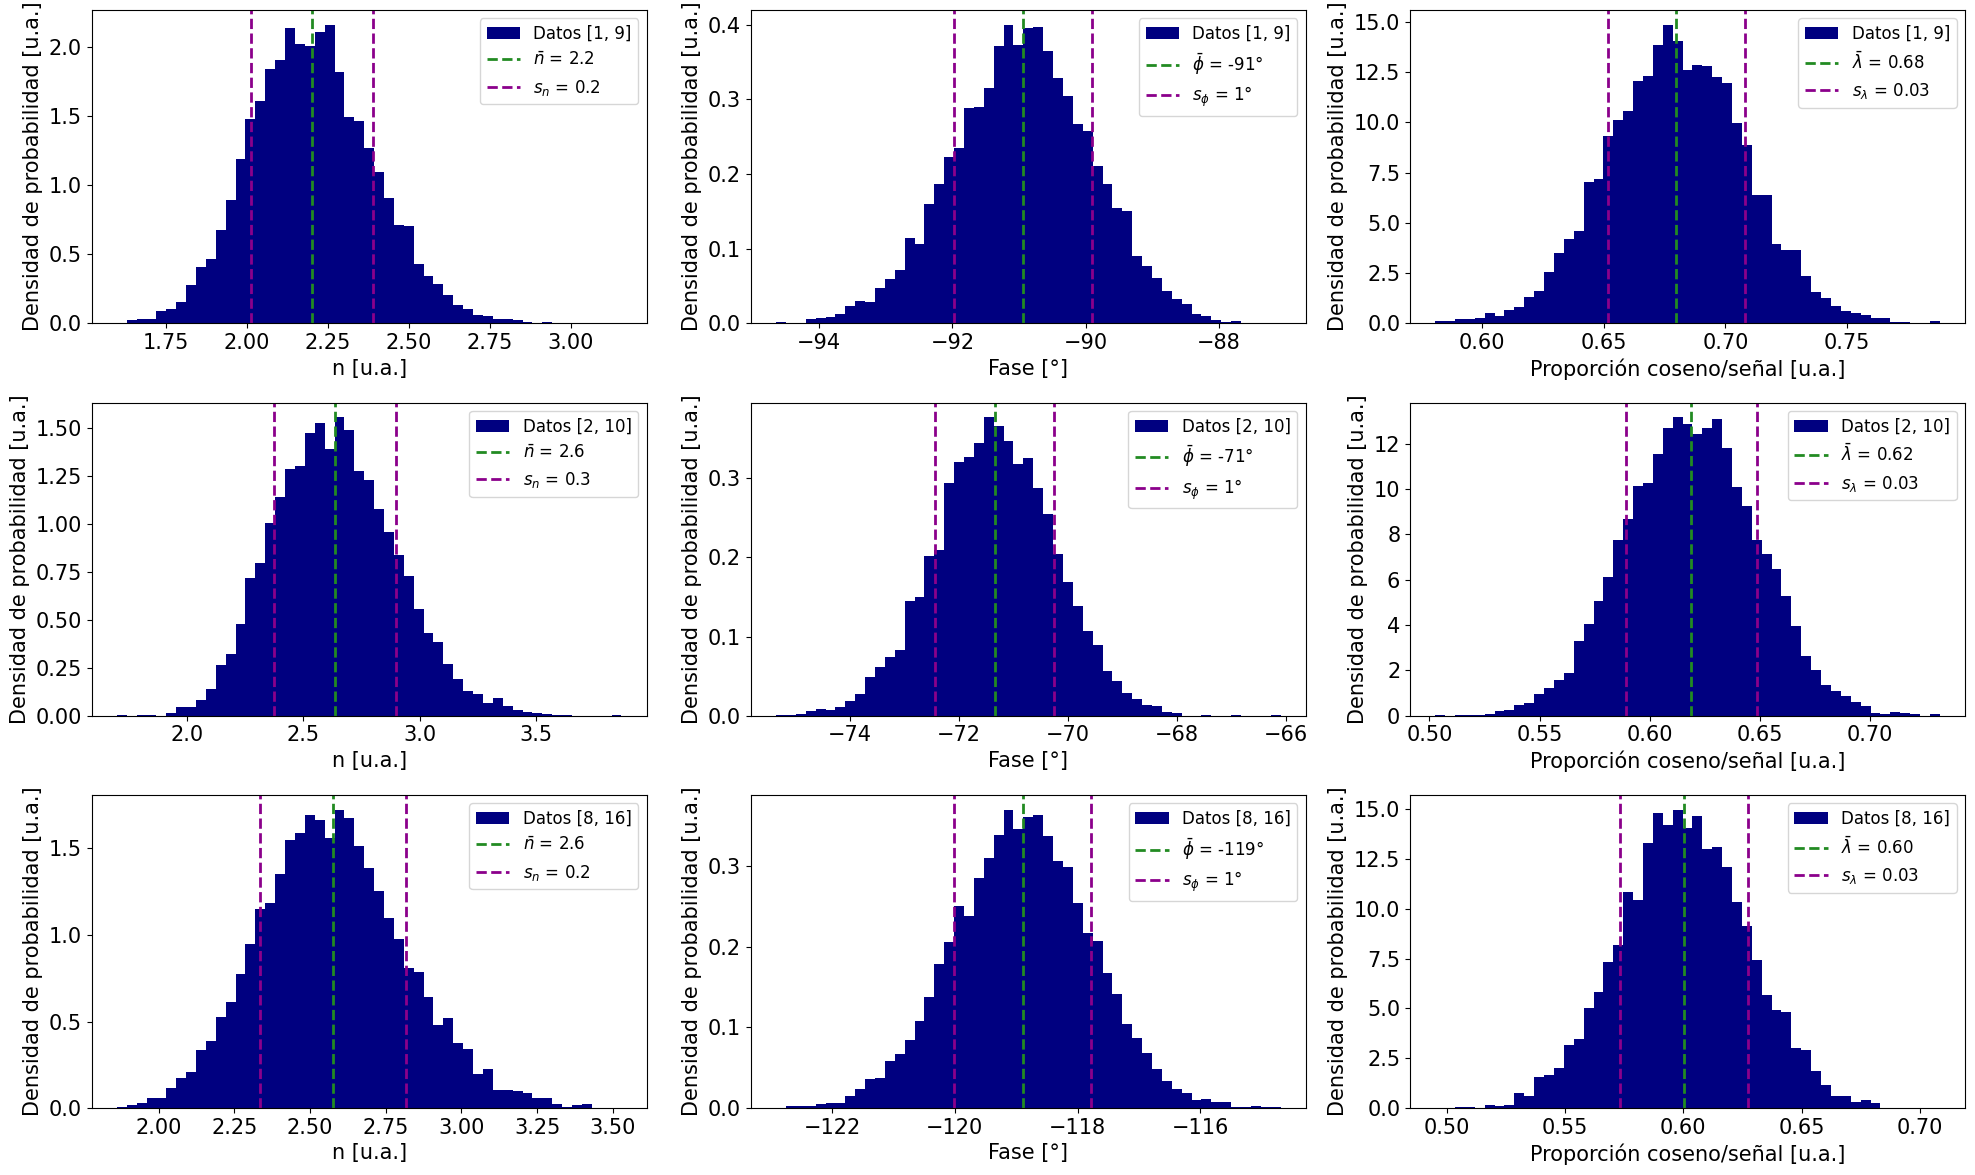

In [58]:
my_pairs = [[1,9],[2,10],[8,16]]
bin_number_pars = 51
fig_hist,axs_hist = plt.subplots(3,3,figsize=(20,12),layout='tight')
axs_hist = axs_hist.flatten()

for i in range(len(my_pairs)):
    pair = my_pairs[i]
    results = pd.read_csv(f'bayesian/ajuste {pair}.csv',header=None,names=['n','phi','lambda'])
    n_samples = np.array(results.n)
    phi_samples = np.array(results.phi)
    lambda_samples = np.array(results['lambda'])
    n_m = np.mean(n_samples)
    err_n = np.std(n_samples)
    phi_m = np.mean(phi_samples)
    err_phi = np.std(phi_samples)
    lambda_m = np.mean(lambda_samples)
    err_lambda = np.std(lambda_samples)

    n_arr = np.linspace(np.min(n_samples),np.max(n_samples),200)
    phi_arr = np.degrees(np.linspace(np.min(phi_samples),np.max(phi_samples),200))
    lambda_arr = np.linspace(np.min(lambda_samples),np.max(lambda_samples),200)
    n_prior = norm.pdf(n_arr,loc=2,scale=1)
    phi_prior = norm.pdf(phi_arr,loc=np.degrees(fases[i]),scale=np.degrees(0.5))
    lambda_prior = beta.pdf(lambda_arr,5,2)
    
    ax_n = axs_hist[3*i]
    ax_phi = axs_hist[3*i+1]
    ax_lambda = axs_hist[3*i+2]
    ax_n.hist(n_samples,bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
    #ax_n.plot(n_arr,n_prior,color='crimson',label='Prior')
    ax_n.axvline(n_m,c='forestgreen',ls='--',label=r'$\bar{n}$'+f' = {n_m:.1f}')
    ax_n.axvline(n_m+err_n,c='darkmagenta',ls='--',label=r'$s_{n}$'+f' = {err_n:.1f}')
    ax_n.axvline(n_m-err_n,c='darkmagenta',ls='--')
    ax_n.set_xlabel('n [u.a.]')
    ax_n.set_ylabel('Densidad de probabilidad [u.a.]')
    ax_n.legend(fontsize=12)
    ax_phi.hist(np.degrees(phi_samples),bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
    #ax_phi.plot(phi_arr,phi_prior,color='crimson',label='Prior')
    ax_phi.axvline(np.degrees(phi_m),c='forestgreen',ls='--',label=r'$\bar{\phi}$'+f' = {np.degrees(phi_m):.0f}°')
    ax_phi.axvline(np.degrees(phi_m+err_phi),c='darkmagenta',ls='--',label=r'$s_{\phi}$'+f' = {np.degrees(err_phi):.0f}°')
    ax_phi.axvline(np.degrees(phi_m-err_phi),c='darkmagenta',ls='--')
    ax_phi.set_xlabel('Fase [°]')
    ax_phi.set_ylabel('Densidad de probabilidad [u.a.]')
    ax_phi.legend(fontsize=12)
    ax_lambda.hist(lambda_samples,bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
    #ax_lambda.plot(lambda_arr,lambda_prior,color='crimson',label='Prior')
    ax_lambda.axvline(lambda_m,c='forestgreen',ls='--',label=r'$\bar{\lambda}$'+f' = {lambda_m:.2f}')
    ax_lambda.axvline(lambda_m+err_lambda,c='darkmagenta',ls='--',label=r'$s_{\lambda}$'+f' = {err_lambda:.2f}')
    ax_lambda.axvline(lambda_m-err_lambda,c='darkmagenta',ls='--')
    ax_lambda.set_xlabel('Proporción coseno/señal [u.a.]')
    ax_lambda.set_ylabel('Densidad de probabilidad [u.a.]')
    ax_lambda.legend(fontsize=12)
plt.savefig('plots informe/parámetros pares.png')

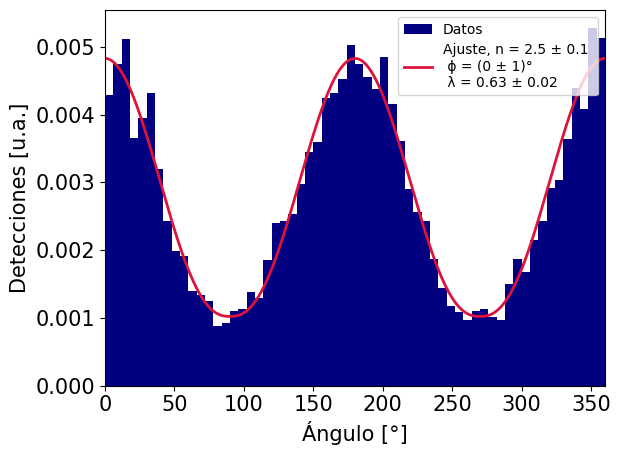

In [63]:
conversion_factor = np.pi/180
bin_width = 9.619727799698852*2
bin_number = 61

pair = my_pairs[0]
df_full = filtrar_coincidencias(filtered_df,[pair])
df_full.ang -= np.degrees(fases_posta[0])
for i in range(1,len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    df_pair.ang -= np.degrees(fases_posta[i])
    df_full = pd.concat([df_full,df_pair]).reset_index(drop=True)
df_full.ang = np.mod(df_full.ang,360)

results = pd.read_csv(f'bayesian/ajuste todos.csv',header=None,names=['n','phi','lambda'])
n_samples = np.array(results.n)
phi_samples = np.array(results.phi)
lambda_samples = np.array(results['lambda'])
n_m = np.mean(n_samples)
err_n = np.std(n_samples)
phi_m = np.mean(phi_samples)
err_phi = np.std(phi_samples)
lambda_m = np.mean(lambda_samples)
err_lambda = np.std(lambda_samples)

x_adj = np.linspace(0,360,1000)
Z_val = 2*np.sqrt(np.pi)*gamma((n_m+1)/2)/gamma(n_m/2+1)
y_muon = (np.abs(np.cos(np.radians(x_adj)-phi_m))**n_m)/Z_val*conversion_factor
y_ruido = np.full_like(x_adj,1/(2*np.pi))*conversion_factor
y_adj = (lambda_m*y_muon)+((1-lambda_m)*y_ruido)
    
plt.hist(df_full.ang,bins=np.linspace(0,360,bin_number),density=True,color='navy',label=f'Datos')
plt.plot(x_adj,y_adj,color='crimson',label=f'Ajuste, n = {n_m:.1f} \u00b1 {err_n:.1f} \n \u03d5 = ({abs(np.degrees(phi_m)):.0f} \u00b1 {np.degrees(err_phi):.0f})° \n \u03bb = {lambda_m:.2f} \u00b1 {err_lambda:.2f}')
plt.xlim(0,360)
plt.legend(fontsize=10,loc=1)
plt.xlabel('Ángulo [°]')
plt.ylabel('Detecciones [u.a.]')
plt.savefig('plots informe/ajuste todos.png')

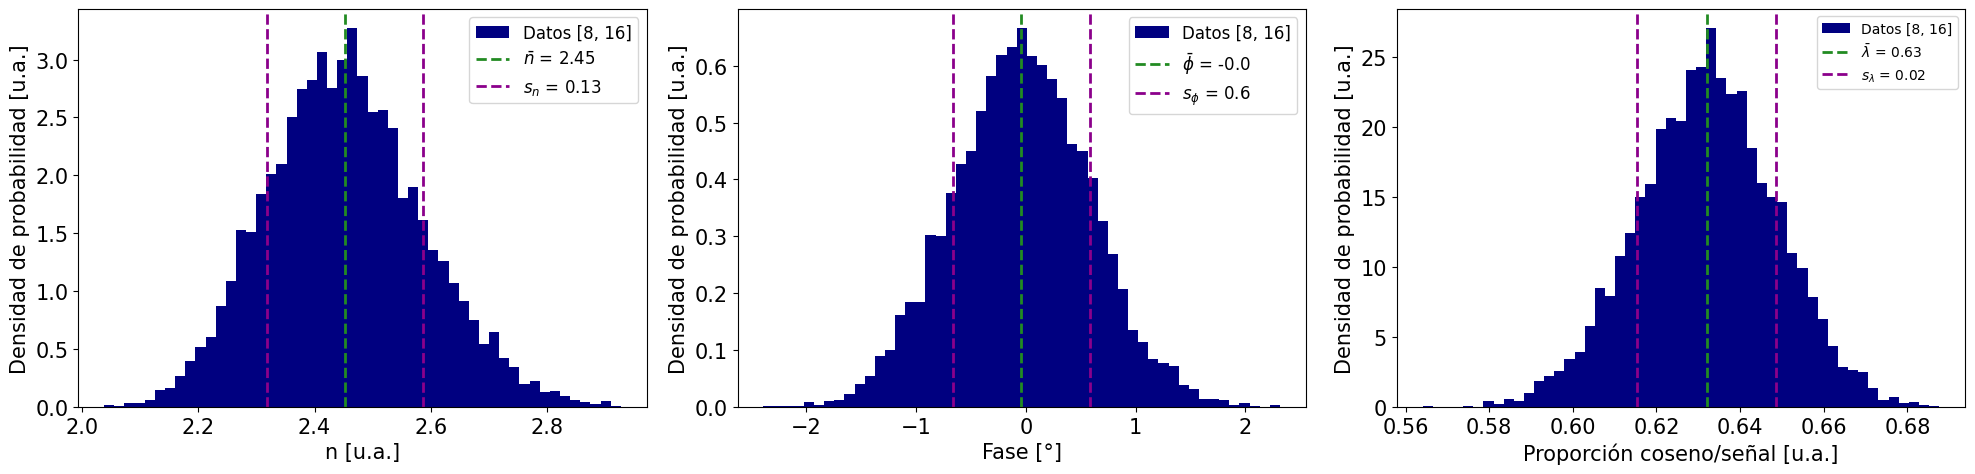

In [70]:
my_pairs = [[1,9],[2,10],[8,16]]
bin_number_pars = 51
fig_hist,axs_hist = plt.subplots(1,3,figsize=(20,5),layout='tight')
axs_hist = axs_hist.flatten()

results = pd.read_csv(f'bayesian/ajuste todos.csv',header=None,names=['n','phi','lambda'])
n_samples = np.array(results.n)
phi_samples = np.array(results.phi)
lambda_samples = np.array(results['lambda'])
n_m = np.mean(n_samples)
err_n = np.std(n_samples)
phi_m = np.mean(phi_samples)
err_phi = np.std(phi_samples)
lambda_m = np.mean(lambda_samples)
err_lambda = np.std(lambda_samples)

n_arr = np.linspace(np.min(n_samples),np.max(n_samples),200)
phi_arr = np.degrees(np.linspace(np.min(phi_samples),np.max(phi_samples),200))
lambda_arr = np.linspace(np.min(lambda_samples),np.max(lambda_samples),200)
n_prior = norm.pdf(n_arr,loc=2,scale=1)
phi_prior = norm.pdf(phi_arr,loc=np.degrees(0),scale=np.degrees(0.5))
lambda_prior = beta.pdf(lambda_arr,5,2)
    
ax_n = axs_hist[0]
ax_phi = axs_hist[1]
ax_lambda = axs_hist[2]
ax_n.hist(n_samples,bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
#ax_n.plot(n_arr,n_prior,color='crimson',label='Prior')
ax_n.axvline(n_m,c='forestgreen',ls='--',label=r'$\bar{n}$'+f' = {n_m:.2f}')
ax_n.axvline(n_m+err_n,c='darkmagenta',ls='--',label=r'$s_{n}$'+f' = {err_n:.2f}')
ax_n.axvline(n_m-err_n,c='darkmagenta',ls='--')
ax_n.set_xlabel('n [u.a.]')
ax_n.set_ylabel('Densidad de probabilidad [u.a.]')
ax_n.legend(fontsize=12)
ax_phi.hist(np.degrees(phi_samples),bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
#ax_phi.plot(phi_arr,phi_prior,color='crimson',label='Prior')
ax_phi.axvline(np.degrees(phi_m),c='forestgreen',ls='--',label=r'$\bar{\phi}$'+f' = {np.degrees(phi_m):.1f}')
ax_phi.axvline(np.degrees(phi_m+err_phi),c='darkmagenta',ls='--',label=r'$s_{\phi}$'+f' = {np.degrees(err_phi):.1f}')
ax_phi.axvline(np.degrees(phi_m-err_phi),c='darkmagenta',ls='--')
ax_phi.set_xlabel('Fase [°]')
ax_phi.set_ylabel('Densidad de probabilidad [u.a.]')
ax_phi.legend(fontsize=12)
ax_lambda.hist(lambda_samples,bins=bin_number_pars,density=True,color='navy',label=f'Datos {pair}')
#ax_lambda.plot(lambda_arr,lambda_prior,color='crimson',label='Prior')
ax_lambda.axvline(lambda_m,c='forestgreen',ls='--',label=r'$\bar{\lambda}$'+f' = {lambda_m:.2f}')
ax_lambda.axvline(lambda_m+err_lambda,c='darkmagenta',ls='--',label=r'$s_{\lambda}$'+f' = {err_lambda:.2f}')
ax_lambda.axvline(lambda_m-err_lambda,c='darkmagenta',ls='--')
ax_lambda.set_xlabel('Proporción coseno/señal [u.a.]')
ax_lambda.set_ylabel('Densidad de probabilidad [u.a.]')
ax_lambda.legend(fontsize=10)
plt.savefig('plots informe/parámetros todos.png')

In [37]:
def sampling_teo(n,phi,prop,N_samples=10000,seed=0):
    rng = np.random.default_rng(seed)
    samples = []
    filled = 0
    p_uniform = 1-prop

    while len(samples) < N_samples:
        size = N_samples-len(samples)
        sample_uniform = rng.random(size) < p_uniform
        size_uniform = np.sum(sample_uniform)
        if size_uniform > 0:
            samples_uniform = rng.uniform(0,360,size_uniform)
            samples.extend(samples_uniform)
        size_cos = size - size_uniform
        if size_cos > 0:
            samples_cos = []
            while len(samples_cos) < size_cos:
                size_cos_needed = (size_cos - len(samples_cos))*3
                first_sample_deg = rng.uniform(0,360,size_cos_needed)
                first_sample_rad = np.radians(first_sample_deg)
                u = rng.random(size_cos_needed)
                accept = u < np.abs(np.cos(first_sample_rad-phi))**n
                samples_cos.extend(first_sample_deg[accept])
            samples.extend(samples_cos[:size_cos])
    return np.array(samples)

p-valor de Kolmogorov: 0.9488903764715887


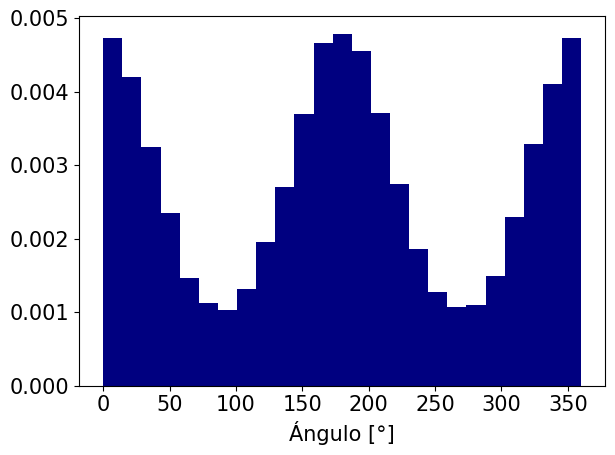

In [40]:
sample_teo = sampling_teo(n_m,phi_m,lambda_m,N_samples=int(1e5))
plt.hist(sample_teo,bins=25,density=True,color='navy')
plt.xlabel('Ángulo [°]')

print(f'p-valor de Kolmogorov: {kstest(df_full.ang,sample_teo).pvalue}')

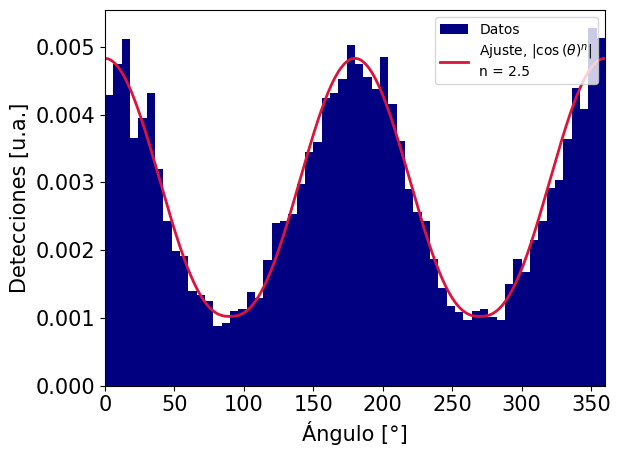

In [17]:
conversion_factor = np.pi/180
bin_width = 9.619727799698852*2
bin_number = 61

pair = my_pairs[0]
df_full = filtrar_coincidencias(filtered_df,[pair])
df_full.ang -= np.degrees(fases_posta[0])
for i in range(1,len(my_pairs)):
    pair = my_pairs[i]
    df_pair = filtrar_coincidencias(filtered_df,[pair])
    df_pair.ang -= np.degrees(fases_posta[i])
    df_full = pd.concat([df_full,df_pair]).reset_index(drop=True)
df_full.ang = np.mod(df_full.ang,360)

results = pd.read_csv(f'bayesian/ajuste todos.csv',header=None,names=['n','phi','lambda'])
n_samples = np.array(results.n)
phi_samples = np.array(results.phi)
lambda_samples = np.array(results['lambda'])
n_m = np.mean(n_samples)
err_n = np.std(n_samples)
phi_m = np.mean(phi_samples)
err_phi = np.std(phi_samples)
lambda_m = np.mean(lambda_samples)
err_lambda = np.std(lambda_samples)

x_adj = np.linspace(0,360,1000)
Z_val = 2*np.sqrt(np.pi)*gamma((n_m+1)/2)/gamma(n_m/2+1)
y_muon = (np.abs(np.cos(np.radians(x_adj)-phi_m))**n_m)/Z_val*conversion_factor
y_ruido = np.full_like(x_adj,1/(2*np.pi))*conversion_factor
y_adj = (lambda_m*y_muon)+((1-lambda_m)*y_ruido)
    
plt.hist(df_full.ang,bins=np.linspace(0,360,bin_number),density=True,color='navy',label=f'Datos')
plt.plot(x_adj,y_adj,color='crimson',label=r'Ajuste, $|\cos{(\theta)}^{n}|$' + f'\nn = {n_m:.1f}')
plt.xlim(0,360)
plt.legend(fontsize=10,loc=1)
plt.xlabel('Ángulo [°]')
plt.ylabel('Detecciones [u.a.]')
plt.savefig('plot video.png')